In [147]:
%load_ext autoreload
%autoreload 2   

import arviz as az
import numpy as np
import pandas as pd

from pyprojroot import here

import pymc as pm

import mmm_utils.plot as mmm_plot
import mmm_utils.post_modeling as mmm_post_plot
from mmm_utils import Timeline
from mmm_utils.data_logger import data_logger

data_logger.change_dir(here() / "work" / "logs")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the data and plotting spend and sales

In [148]:
file_path = here() / "examples" / "synthetic_mm_data.csv"
data = pd.read_csv(file_path, sep=";", decimal=".").fillna(0)

data["date"] = pd.to_datetime(data["date"])
data["intercept"] = 1
data["trend"] = np.linspace(0, 1, len(data))

media = ["TV", "SEA", "Digital"]
# data[media] = data[media].apply(lambda x: x - x.mean(), axis=0)
data["SEA"] = data["SEA"] - data["SEA"].min()

controls = ["intercept", "trend", "school_holidays", "price"]
# data["price"] = data["price"] - data["price"].min()

X = data[media + controls + ["date"]]
y = data["y"]

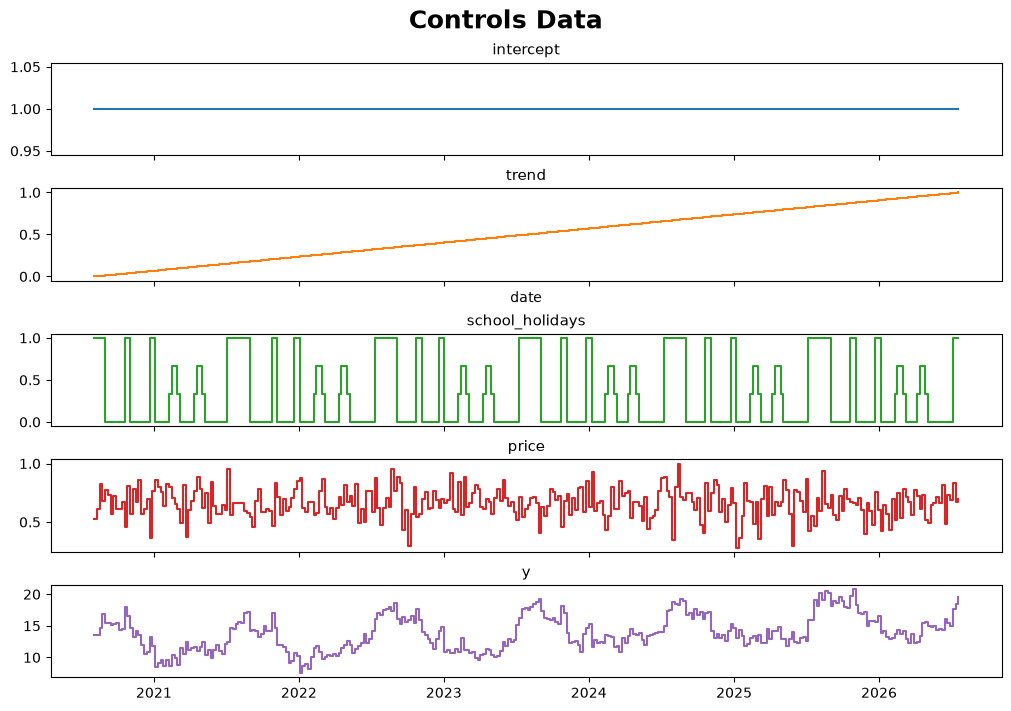

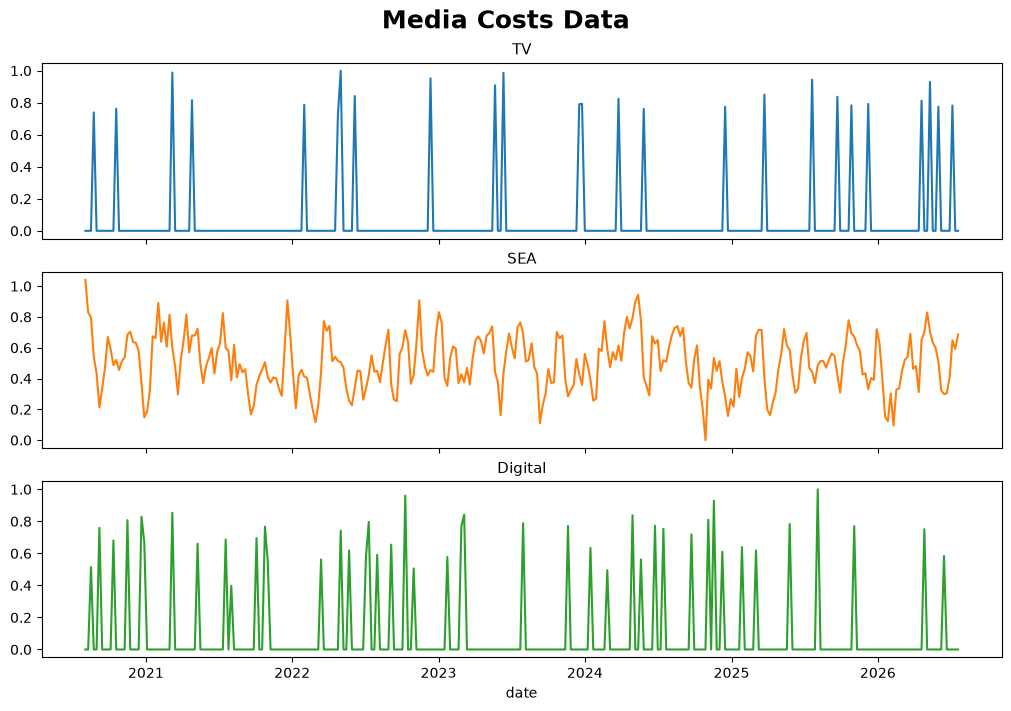

In [149]:
fig, axes = mmm_plot.plot_controls_variable(data, controls + ["y"])
fig, axes = mmm_plot.plot_media_costs(data, media)

## Modeling

In [150]:
from mmm_utils.modeling import MMM, MMMConfig, MediaTransformSpec
from mmm_utils.modeling.prior import PriorSpec, plot_prior_vs_posterior
from mmm_utils.modeling import Interaction, BetaPriors

In [151]:
interaction = Interaction(
    formulas={
        "TV": "1",
        "SEA": "1",  # + TV",
        "Digital": "1",  # + TV",
    },
    media=media,
    # is_shared_with=[("TV", "SEA", "Digital")],
)
print("Priors that need to be defined :")
interaction.get_unique_parameter_names()

Priors that need to be defined :


set()

In [152]:
beta_priors = BetaPriors(
    interaction=interaction,
    priors={},  # "beta_interaction_TV": PriorSpec("HalfNormal", {"sigma": 0.5})},
    season=PriorSpec("Laplace", {"mu": 0.0, "b": np.array([0.5, 0.5, 0.1, 0.1])}),
    control=PriorSpec("Normal", {"mu": 1.0, "sigma": 9.1}),
)

In [153]:
cfg = MMMConfig(
    media_names=media,
    control_names=controls,
    seasonality_order=2,
    beta_priors=beta_priors,
    media_transforms={
        "TV": MediaTransformSpec(
            adstock="Geometric",
            adstock_params={"l_max": 36},
            adstock_priors={
                "alpha": PriorSpec("Beta", {"alpha": 4.0, "beta": 0.5}),
                # "theta": PriorSpec("Normal", {"mu": 2, "sigma": 0.2}),
            },
            saturation="Logistic",
            saturation_params={"lam": 3.0},
            saturation_priors={
                # "lam": PriorSpec("LogNormal", {"mu": 0.0, "sigma": 1.0})
            },
        ),
        "SEA": MediaTransformSpec(
            adstock="Geometric",
            adstock_params={"l_max": 12, "alpha": 0.0},
            adstock_priors={},  # "alpha": PriorSpec("Beta", {"alpha": 2.0, "beta": 2.0})},
            saturation="Logistic",
            saturation_params={"lam": 1.0},
            # saturation_priors={
            #     "lam": PriorSpec("LogNormal", {"mu": 0.0, "sigma": 1.0})
            # },
        ),
        "Digital": MediaTransformSpec(
            adstock="Geometric",
            adstock_params={"l_max": 12},
            adstock_priors={
                "alpha": PriorSpec("Beta", {"alpha": 4.0, "beta": 0.5}),
            },
            saturation="Logistic",
            saturation_params={"lam": 1.0},
            saturation_priors={
                # "lam": PriorSpec("LogNormal", {"mu": 0.0, "sigma": 1.0})
            },
        ),
    },
)

mmm = MMM(cfg)

#### Model Building

In [154]:
mmm.build(X, y, rescale=False)

{'l_max': 36, 'alpha': adstock_alpha_agrp0}
{'l_max': 12, 'alpha': 0.0}


/home/acaillebotte/projects/MMM/mmm_utils/mmm_utils/modeling/mmm.py:194: UserWarning: Channels ['TV', 'Digital'] have different l_max values [36, 12]. Using l_max=36 (maximum) for all channels in this adstock group.
  x_transformed = handler.apply(x_m)


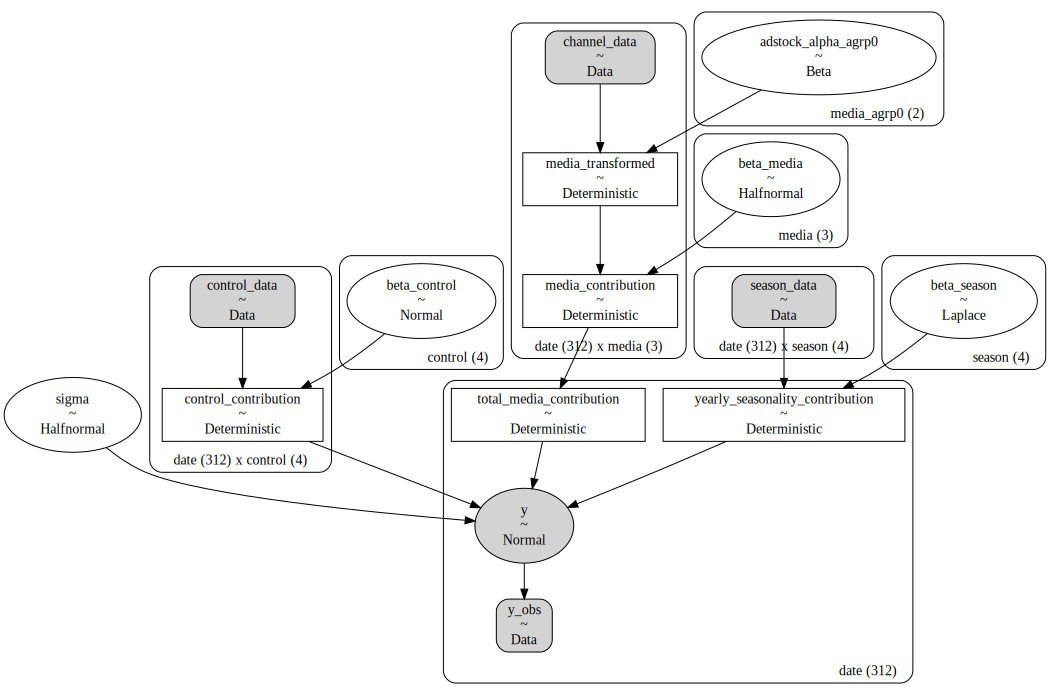

In [155]:
pm.model_to_graphviz(model=mmm.model, var_names=["y_obs"])

#### Model Fitting

In [156]:
mmm.fit(
    draws=500,
    tune=500,
    chains=2,
    cores=2,
    target_accept=0.975,
)

NUTS[numpyro]: [beta_media, beta_control, beta_season, adstock_alpha_agrp0, sigma]
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{0 < alpha <= 1} Op (assertion: 0 < alpha <= 1) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/acaillebotte/projects/MMM/mmm_utils/.venv/lib/python3.12/site-packages/pymc/sampling/mcmc.py:995: FutureWarning: `passing log_likelihood` is deprecated and will be removed in future versions. Use :func:`pymc.compute_log_likelihood` instead.
  return _sample_external_nuts(
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{0 < alpha <= 1} Op (assertion: 0 < alpha <= 1) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:909: UserWarning: Skipping Check{0 < alpha <= 1} Op (assertion: 0 < alpha <= 1) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [157]:
mmm.sample_posterior_predictive()
_ = mmm.compute_contributions()

Sampling: [y]


Output()

Sampling: [adstock_alpha_agrp0, beta_control, beta_media, beta_season, sigma, y]


Output()

## Post-modeling analysis

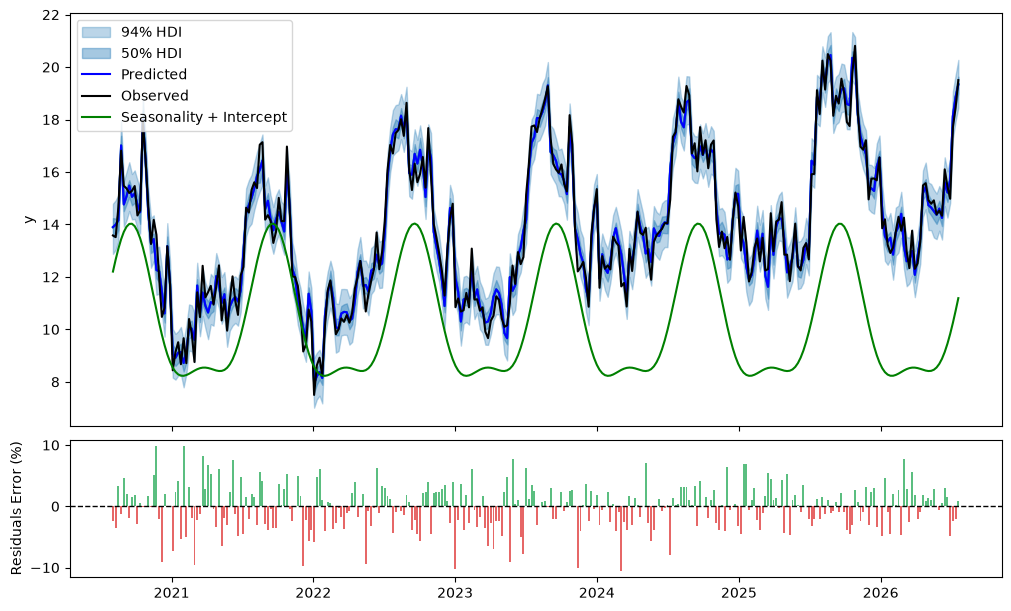

In [158]:
fig, ax = mmm_post_plot.plot_posterior_predictive_y(mmm, True, True)

In [159]:
az.residual_r2(mmm.idata, "y", group="posterior_predictive")

residual_R2(mean=0.94, eti_lb=0.94, eti_ub=0.95)

## ROPE analysis & Estimation printing

In [160]:
mmm_post_plot.rope_probability_test(
    posterior=mmm.idata.posterior,
    var=cfg.var_names,
    rope=(-0.1, 0.1),
    verbatim=False,
)

,rope_low,rope_high,lower,in,greater,decision
parameter,,,,,,
beta_season[cos[2]],-3.72e-03,3.72e-03,0.89 (**),0.04,0.07,?


/tmp/ipykernel_474811/3140314386.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box_parts = ax.boxplot(
/tmp/ipykernel_474811/3140314386.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  violin_parts = ax.violinplot(


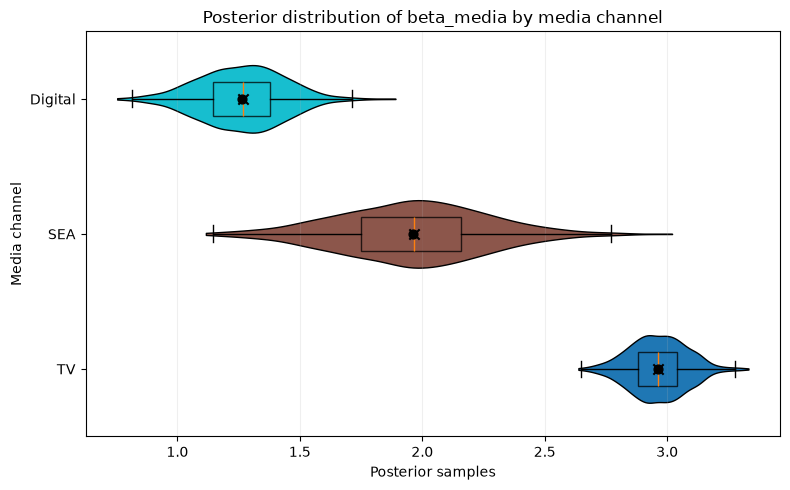

In [161]:
all_beta = mmm.idata.posterior.beta_media
data_logger.direct_to_csv(
    "posterior_beta_draws.csv", dataframe=all_beta.to_dataframe().reset_index()
)


import matplotlib.pyplot as plt


beta_media_samples = [
    all_beta.sel(media=media_name).values.reshape(-1) for media_name in media
]
positions = np.arange(1, len(media) + 1)
cmap = plt.get_cmap("tab10")
colors = cmap(np.linspace(0, 1, len(media)))

fig, ax = plt.subplots(figsize=(8, 5))

# Horizontal boxplot (background)
box_parts = ax.boxplot(
    beta_media_samples,
    positions=positions,
    widths=0.25,
    patch_artist=True,
    showfliers=False,
    vert=False,
    zorder=2,
)

# Horizontal violin plot (foreground)
violin_parts = ax.violinplot(
    beta_media_samples,
    positions=positions,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    vert=False,
)

for idx in range(len(media)):
    patch = box_parts["boxes"][idx]
    patch.set_facecolor(colors[idx])
    patch.set_edgecolor("black")
    patch.set_alpha(0.75)

    body = violin_parts["bodies"][idx]
    body.set_facecolor(colors[idx])
    body.set_edgecolor("black")
    body.set_alpha(1.0)
    body.set_zorder(1)

# --- Mean ---
means = np.array([samples.mean() for samples in beta_media_samples])
ax.scatter(means, positions, color="black", marker="o", s=40, zorder=3)
# --- Median ---
medians = np.array([np.median(samples) for samples in beta_media_samples])
ax.scatter(medians, positions, color="black", marker="x", s=55, zorder=4)

ax.set_yticks(positions)
ax.set_yticklabels(media)
ax.set_xlabel("Posterior samples")
ax.set_ylabel("Media channel")
ax.set_title("Posterior distribution of beta_media by media channel")
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

In [162]:
estim = (
    az.summary(data=mmm.idata.posterior, var_names=cfg.var_names)
    .reset_index()
    .rename(columns={"index": "parameter"})
)

value_columns = [col for col in estim.columns if col != "parameter"]
estim[value_columns] = (
    estim[value_columns].apply(pd.to_numeric, errors="coerce").astype(float)
)

In [163]:
estim

,parameter,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
0,beta_media[TV],2.9630,0.1160,2.80,3.1000,812.0,777.0,1.00,0.00410,0.00280
1,beta_media[SEA],1.9600,0.3000,1.50,2.4000,1233.0,614.0,1.01,0.00870,0.00610
2,beta_media[Digital],1.2620,0.1740,0.98,1.5000,1247.0,683.0,1.00,0.00490,0.00350
3,beta_control[intercept],10.2700,0.2100,9.90,11.0000,559.0,665.0,1.00,0.00890,0.00640
4,beta_control[trend],4.0530,0.1070,3.90,4.2000,1032.0,747.0,1.00,0.00330,0.00230
5,beta_control[school_holidays],2.0570,0.0700,1.90,2.2000,999.0,594.0,1.00,0.00220,0.00160
6,beta_control[price],-2.4900,0.2100,-2.80,-2.1000,779.0,606.0,1.00,0.00740,0.00560
7,adstock_alpha_agrp0[TV],0.8985,0.0050,0.89,0.9100,772.0,604.0,1.00,0.00018,0.00014
8,adstock_alpha_agrp0[Digital],0.8300,0.0410,0.76,0.8900,1181.0,803.0,1.00,0.00120,0.00100
9,beta_season[sin[1]],1.9040,0.0420,1.80,2.0000,1385.0,795.0,1.00,0.00110,0.00078


In [164]:
def robustness_check(estim, filter=None):
    def _classify(lo: float, hi: float, center: float) -> dict:
        """Return the level dict for the given ETI 89% bounds.

        Parameters
        ----------
        lo, hi   : ETI 89% lower / upper bounds (eti89_lb, eti89_ub).
        center   : posterior mean used as point estimate for relative width.
        """
        overlaps_zero = lo < 1e-9
        # Compute relative width as a fraction of the center (mean) value.
        rel_width = (hi - lo) / max(abs(center), 1e-9)

        if not overlaps_zero and rel_width <= 0.30:
            return "Robuste"
        if not overlaps_zero and rel_width <= 0.80:
            return "Acceptable"
        if overlaps_zero and rel_width > 0.80:
            return "Non identifié"
        return "Fragile"

    results = []
    for _, row in estim.iterrows():
        level = _classify(row["eti89_lb"], row["eti89_ub"], row["mean"])
        results.append({"parameter": row["parameter"], "robustness_level": level})

    if filter is not None:
        results = [r for r in results if r["robustness_level"] == filter]

    return pd.DataFrame(results)


robustness_check(estim, "Fragile")

,parameter,robustness_level
0,beta_control[price],Fragile


In [165]:
high_mcse_variables = mmm_post_plot.summarize_high_mcse_mean(estim)

high_mcse_variables.round({"mcse_over_sd": 2})

,parameter,mcse_mean,mcse_over_sd,decision


In [166]:
# signal_std = np.std(y_true)
# noise_std = estim.loc[estim["parameter"] == "sigma", "mean"].values[0]
# snr = signal_std / noise_std

# print(f"Signal std: {signal_std:.4f}")
# print(f"Noise std (sigma): {noise_std:.4f}")
# print(f"Signal-to-Noise Ratio (SNR): {snr:.2f}")

In [167]:
mmm_post_plot.adstock_to_half_life(mmm, media).round(
    {"adstock_alpha": 3, "half_life": 2}
)

AttributeError: 'Dataset' object has no attribute 'to_dataset'

## Ploting priors and posteriors

In [ ]:
# plot_prior_vs_posterior(
#     mmm, "beta_interaction_TV", None, separately=False, figsize=(6, 6)
# )

In [ ]:
plot_prior_vs_posterior(mmm, "beta_media", media, separately=False)
plot_prior_vs_posterior(mmm, "beta_control", controls, separately=False)
plot_prior_vs_posterior(
    mmm,
    "beta_season",
    mmm.idata.posterior.season.values,
    separately=False,
    figsize=(12, 6),
)

coords = list(mmm.model.coords.keys())
coords
media_pattern_coords = [
    (coord_name, coord_name.split("media_")[1])
    for coord_name in coords
    if coord_name.startswith("media_")
]
media_pattern_coords

for vr_names in list(mmm.model.named_vars.keys()):
    for coord_name, media_name in media_pattern_coords:
        if media_name in vr_names:
            plot_prior_vs_posterior(
                mmm,
                vr_names,
                mmm.idata.posterior[coord_name].values,
                separately=True,
                figsize=(10, 6),
            )

### Adstock Effects Interpretation

In [ ]:
fig, ax = mmm_post_plot.plot_adstock_effects(data, mmm, media=media)

## Timeline

In [ ]:
timeline = Timeline(
    mmm.idata.posterior,
    data,
    media=media,
    controls=["trend", "school_holidays", "price"],
    baseline_components=["intercept", "yearly_seasonality"],
    target_scale=mmm.data.scale("y"),
    target="y",
)

timeline.outcome_df.head()

In [ ]:
fig, ax = mmm_plot.plot_contributions(
    timeline,
    channels=media + ["trend", "price", "school_holidays"],
    decomposition=False,
    plot_y=True,
    remove_baseline=False,
    ascending=False,
)

In [ ]:
_ = mmm_plot.plot_summary_contributions(
    timeline,
    controls=[],
    baseline_override=[],
)

_ = mmm_plot.plot_summary_contributions_per_media(
    timeline, controls=["trend", "promo", "price"]
)

# Saturation & Optimization

In [168]:
saturation_curves = mmm.sample_saturation_curves(x_max=2.0)

Sampling: []
Sampling: []
Sampling: []


In [169]:
media_scales = mmm.data.scale("media")

saturation = []
for i, m in enumerate(media):
    curve = saturation_curves[m]
    sat_name = f"saturation_{m}"

    xx = (curve.coords["x"]).values * media_scales[m]
    beta = (
        mmm.idata.posterior[f"beta_media"]
        .sel(media=m)
        .mean(dim=["chain", "draw"])
        .values
    )
    yy = beta * curve.mean(dim=["chain", "draw"]).values * mmm.data.scale("y")

    saturation.append(
        {
            "name": m,
            "values": {str(int(xx[k])): float(yy[k]) for k in range(len(xx))},
        }
    )

# _ = mmm_plot.plot_saturation_curves(saturation_curves, mmm, data=data, media=media)

In [170]:
from mmm_utils.optimize import (
    get_recommended_budget,
    get_current_budget,
    print_optimization_results,
)

flexibilities = {"low": 0.1, "medium": 0.2, "high": 0.3}

all_budgets = {
    type: get_recommended_budget(
        mmm,
        mmm.config.media_names,
        campaign_period=4 * 4,
        flexibility=flexibilities[type],
        constant_budget=True,
    )
    for type in flexibilities.keys()
}

	 Starting Optimization
✅ Budget template created :
	<xarray.DataArray (date: 1, media: 3)> Size: 24B
array([[0.06715037, 0.50240418, 0.0990315 ]])
Coordinates:
  * date     (date) datetime64[us] 8B 2026-07-27
  * media    (media) <U7 84B 'TV' 'SEA' 'Digital'
✅ Replacing RVs with posterior samples in the graph:
	 * beta_media 	 with constant beta_media{[[2.852524 ... 49150045]]}
	 * adstock_alpha_agrp0 	 with constant adstock_alpha_agrp0{[[0.893652 ... 81377235]]}

⌛Budget 0.6686, Remaining Budget 5.42e-12, Objective -2.27e+00, 
⌛Budget 0.6686, Remaining Budget 5.42e-12, Objective -2.27e+00, 
Budget constraint satisfied.
Budget bounds satisfied for all media.
	 Starting Optimization
✅ Budget template created :
	<xarray.DataArray (date: 1, media: 3)> Size: 24B
array([[0.06715037, 0.50240418, 0.0990315 ]])
Coordinates:
  * date     (date) datetime64[us] 8B 2026-07-27
  * media    (media) <U7 84B 'TV' 'SEA' 'Digital'
✅ Replacing RVs with posterior samples in the graph:
	 * beta_media 	 wi

In [171]:
current_budget = get_current_budget(mmm, media)
total_budget = data[media].mean().to_dict()
x = pd.DataFrame(
    {
        "media": current_budget.keys(),
        "current_budget": current_budget.values(),
    },
)

x["current_budget"] = total_budget.values()
x["current"] = x["current_budget"] / sum(x["current_budget"]) * 100

for flex in all_budgets.keys():
    x[f"plan_{flex}"] = np.array(list(all_budgets[flex].values())).mean(axis=1)

    x[f"reco_{flex}"] = x[f"plan_{flex}"] / sum(x["current_budget"]) * 100
    x[f"change_{flex}"] = x[f"plan_{flex}"] / x["current_budget"] * 100 - 100

    x[f"plan_{flex}"] = x[f"reco_{flex}"] * sum(x["current_budget"]) / 100

    numeric_columns = x.select_dtypes(include=[np.number]).columns
# total_row = {"media": "total", **x[numeric_columns].sum().to_dict()}
# x = pd.concat([x, pd.DataFrame([total_row])], ignore_index=True)

data_logger.direct_to_csv(
    "budget_recommendations.csv",
    dataframe=x.rename(
        columns={
            "change_medium": "change",
            "plan_medium": "plan",
            "reco_medium": "reco",
        }
    ),
)
x.round(
    {
        "current_budget": 0,
        **{f"plan_{flex}": 0 for flex in all_budgets.keys()},
        **{f"reco_{flex}": 1 for flex in all_budgets.keys()},
    }
)
x

,media,current_budget,current,plan_low,reco_low,change_low,plan_medium,reco_medium,change_medium,plan_high,reco_high,change_high
0,TV,0.067150,10.043639,0.073865,11.048003,10.000000,0.080580,12.052367,20.000000,0.087295,13.056731,30.000000
1,SEA,0.502404,75.144281,0.485786,72.658709,-3.307733,0.469168,70.173137,-6.615465,0.452550,67.687566,-9.923198
2,Digital,0.099031,14.812080,0.108935,16.293288,10.000000,0.118838,17.774496,20.000000,0.128741,19.255704,30.000000


# Mongo

In [172]:
post = mmm.idata.posterior
all_contrib = post.media_contribution.sum(dim=["chain", "draw", "date"]).to_numpy()
media_sorted = list(np.array(media)[np.argsort(all_contrib)])

In [173]:
timeline = Timeline(
    post,
    data=data,
    media=media_sorted,
    controls=[],
    target="y",
    baseline_components=controls + ["yearly_seasonality"],
    target_scale=mmm.data.scale("y"),
)

timeline.outcome_df.head()

,date,Baseline,Digital,SEA,TV,y
0,2020-08-03,12.952929,0.000000,0.936421,0.000000,13.580237
1,2020-08-10,13.222127,0.000000,0.768377,0.000000,13.517728
2,2020-08-17,13.110902,0.317943,0.742935,0.000000,14.656384
3,2020-08-24,13.836986,0.265270,0.517539,2.380657,16.813174
4,2020-08-31,11.839117,0.221378,0.419153,2.251425,15.471775


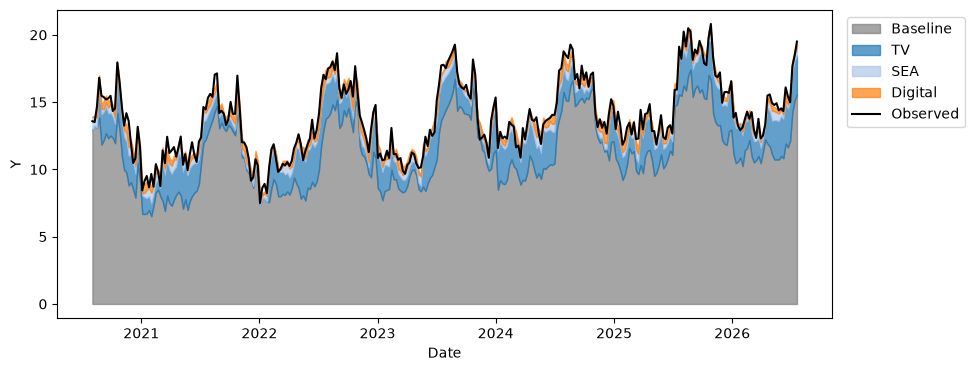

In [174]:
_, ax = mmm_plot.plot_contributions(
    timeline,
    channels=media_sorted,
    decomposition=False,
    plot_y=True,
    remove_baseline=False,
    ascending=False,
)

In [175]:
all_budgets["medium"]

{'TV': array([0.08058044, 0.08058044, 0.08058044, 0.08058044, 0.08058044,
        0.08058044, 0.08058044, 0.08058044, 0.08058044, 0.08058044,
        0.08058044, 0.08058044, 0.08058044, 0.08058044, 0.08058044,
        0.08058044]),
 'SEA': array([0.4691678, 0.4691678, 0.4691678, 0.4691678, 0.4691678, 0.4691678,
        0.4691678, 0.4691678, 0.4691678, 0.4691678, 0.4691678, 0.4691678,
        0.4691678, 0.4691678, 0.4691678, 0.4691678]),
 'Digital': array([0.1188378, 0.1188378, 0.1188378, 0.1188378, 0.1188378, 0.1188378,
        0.1188378, 0.1188378, 0.1188378, 0.1188378, 0.1188378, 0.1188378,
        0.1188378, 0.1188378, 0.1188378, 0.1188378])}

In [176]:
from datetime import datetime, UTC
import os
from pymongo import MongoClient
import pymongo
from dotenv import load_dotenv

load_dotenv()

CODE_MODULE = "MMM_ANTOINE"
DISPLAY_MONGO = {k: [k.replace("_", " ").capitalize()] for k in media_sorted}
recommendations = [
    {
        "name": m,
        "spend": {
            flex: float(all_budgets[flex].get(m, np.array([0])).mean())
            for flex in flexibilities.keys()
        },
    }
    for m in media_sorted
]
timeline_entries = timeline.timeline

In [177]:
doc = {
    "code_module": CODE_MODULE,
    "created_at": datetime.now(UTC).strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z",
    "labels": {
        "currency": "",
        "outcome_unit": "kpi",
        "outcome_contribution": "Contribution des médias au KPI",
        "media_attributed_outcome": "KPI attribué aux médias",
        "cost_per_outcome": "Coût par KPI",
    },
    "mediagroups": DISPLAY_MONGO,
    "recommendations": recommendations,
    "saturation": {
        "media": saturation,
        "details": saturation,
    },
    "timeline": timeline_entries,
    "version": 2,
}

In [178]:
1 / 0

ZeroDivisionError: division by zero

In [179]:
from mmm_utils.utils import LeLabDataBase

db = LeLabDataBase(uri=os.environ.get("MONGO_URI"))
db.update(doc)
# db.insert(doc)

/home/acaillebotte/projects/MMM/mmm_utils/mmm_utils/utils.py:313: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  self._client = MongoClient(uri)
/home/acaillebotte/projects/MMM/mmm_utils/.venv/lib/python3.12/site-packages/pymongo/synchronous/mongo_client.py:1776: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  self._resolve_srv()


MMM_ANTOINE (dated 2026-07-21T12:04:49.347Z) updated successfully ✅
